In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import altair as alt



In [2]:
sns.set_theme("paper")
sns.set_style("white", rc={
})
sns.set_palette("colorblind")


## Data Preparation

In [2]:
character_df = pd.read_parquet("./data/pipeline/hathi_all/final/characters.parquet")

FileNotFoundError: [Errno 2] No such file or directory: './data/pipeline/hathi_all/final/characters.parquet'

In [ ]:
fashion_df = pd.read_parquet("./data/pipeline/hathi_all/final/fashion_mentions.parquet")

In [372]:
hathi_metadata = pd.read_csv("./data/hathimeta/titlemeta.tsv", sep="\t")
hathi_metadata.loc[:, "book_id"] = hathi_metadata.docid.apply(lambda x: x + ".clean")
hathi_metadata = hathi_metadata.set_index("book_id")

/tmp/ipykernel_1359488/3843393713.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  hathi_metadata = pd.read_csv("./data/hathimeta/titlemeta.tsv", sep="\t")


In [ ]:
# read in pronoun data
from pathlib import Path
import json
from fashion.pipeline.steps.extract_pronouns import gender_pronouns


def read_dep_pronoun_data(pron_dir: Path):
    for file in tqdm(pron_dir.glob("*.jsonl")):
        with open(file, "r") as f:
            for line in f:
                obj = json.loads(line)
                if obj["possessive_pronoun"] is None:
                    continue
                for gender, pronouns in gender_pronouns.items():
                    if obj["possessive_pronoun"] in pronouns:
                        yield {
                            "mention_id": obj["mention_id"],
                            "gender": gender,
                        }


def read_pronoun_data(pron_dir: Path):
    for file in tqdm(pron_dir.glob("*.jsonl")):
        with open(file, "r") as f:
            for line in f:
                obj = json.loads(line)
                if len(obj["gender"]) == 0:
                    continue
                agg_gender = max(
                    obj["gender"].keys(), key=lambda x: len(obj["gender"][x])
                )
                yield {
                    "mention_id": obj["mention_id"],
                    "gender": agg_gender,
                    "all_genders": obj["gender"],
                }


loc_pronouns = pd.DataFrame(
    list(read_pronoun_data(Path("./data/pipeline/hathi_all/local_pronouns/")))
)
dep_pronouns = pd.DataFrame(
    list(read_dep_pronoun_data(Path("./data/pipeline/hathi_all/pronouns/")))
)


16it [00:21,  1.36s/it]
16it [00:08,  1.99it/s]


In [10]:
loc_pronouns.gender.value_counts(), dep_pronouns.gender.value_counts()

(gender
 male         2541538
 female       1531799
 nonbinary     633005
 other            206
 Name: count, dtype: int64,
 gender
 male         1028071
 female        546880
 nonbinary     171637
 other             26
 Name: count, dtype: int64)

In [ ]:
merged_fashion_df = fashion_df.merge(
    loc_pronouns.rename({"gender": "gender_local_pron"}, axis=1),
    left_on="mention_id",
    right_on="mention_id",
    how="left",
)
merged_fashion_df = merged_fashion_df.merge(
    dep_pronouns.rename({"gender": "gender_dep_pron"}, axis=1),
    left_on="mention_id",
    right_on="mention_id",
    how="left",
)


In [12]:
# merge fashion and character data

char_fashion = merged_fashion_df.dropna(subset=["character_id"])
char_fashion.character_id = pd.to_numeric(char_fashion.character_id)
char_fashion = char_fashion.set_index(["book_id", "character_id"])


/tmp/ipykernel_1619385/1583668402.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  char_fashion.character_id = pd.to_numeric(char_fashion.character_id)


In [13]:
merged = char_fashion.merge(
    character_df.dropna(subset=["gender"])
    .drop(["character_start_idx", "character_end_idx"], axis=1)
    .rename({"gender": "gender_booknlp"}, axis=1)
    .set_index(["book_id", "character_id"]),
    how="inner",
    left_index=True,
    right_index=True,
    suffixes=("_fashion", "_char"),
)

In [14]:
merged = merged.merge(
    hathi_metadata.inferreddate.dropna(), left_on="book_id", right_index=True
)

In [15]:
merged.loc[:, "decade"] = merged.inferreddate // 10

In [18]:
merged.to_parquet("./data/final_merged.parquet", compression="zstd")

## Data loading

In [6]:
merged = pd.read_parquet("../data/final_merged.parquet")

In [7]:
# we exclude one book that is from 1980s
merged = merged[merged.decade.lt(193)]

In [8]:
merged["decade_clean"] = merged.decade.apply(lambda x: f"{int(x*10)}s")

In [9]:
from fashion.sources import HathiAll


def show(row):
    text = HathiAll().load_text(row.book_id).text
    char_start = int(row.character_start_idx)
    char_end = int(row.character_end_idx)
    print(row.mention_id)
    print(char_start, char_end)
    split = [
        text[row.sentence_start_idx - 50 : char_start],
        text[char_start:char_end],
        text[char_end : row.sentence_end_idx + 50],
    ]
    print(f"{split[0]}[[{split[1]}]]{split[2]}")

In [25]:
merged_no_dupe = (
    merged.reset_index()
    .drop_duplicates(subset=["book_id", "mention_id"])
    .set_index(["book_id", "character_id"])
)

In [26]:
merged_no_dupe.to_parquet("../data/final_for_analysis.parquet")

In [27]:
merged_no_dupe.sample(100_000).to_parquet("../data/sample_for_analysis.parquet")

## Pronoun extraction comparison

In [145]:
def compare_plots(term):
    fig, (local_ax, dep_ax, booknlp_ax, exclude_narrator) = plt.subplots(
        1, 4, figsize=(12, 5), sharey=True
    )
    sns.lineplot(
        data=merged.groupby(["decade", "term"])
        .gender_local_pron.value_counts(normalize=True)[:, term]
        .reset_index(),
        x="decade",
        y="proportion",
        hue="gender_local_pron",
        hue_order=["male", "female", "nonbinary", "None"],
        ax=local_ax,
        # hue_order=["he/him/his", "she/her", "they/them/their", "ze/zem/zir/hir"],
    )
    sns.move_legend(local_ax, "lower right")
    local_ax.set_title("Local Pronoun")

    sns.lineplot(
        data=merged.groupby(["decade", "term"])
        .gender_dep_pron.value_counts(normalize=True)[:, term]
        .reset_index(),
        x="decade",
        y="proportion",
        hue="gender_dep_pron",
        hue_order=["male", "female", "nonbinary", "None"],
        ax=dep_ax,
        # hue_order=["he/him/his", "she/her", "they/them/their", "ze/zem/zir/hir"],
    )
    sns.move_legend(dep_ax, "lower right")
    dep_ax.set_title("Dep Pronoun")

    sns.lineplot(
        data=merged.groupby(["decade", "term"])
        .gender_booknlp.value_counts(normalize=True)[:, term]
        .reset_index(),
        x="decade",
        y="proportion",
        hue="gender_booknlp",
        hue_order=["he/him/his", "she/her", "they/them/their", "ze/zem/zir/hir"],
        ax=booknlp_ax,
    )
    sns.move_legend(booknlp_ax, "lower right")
    booknlp_ax.set_title("BookNLP")

    sns.lineplot(
        data=merged[merged.index.get_level_values("character_id") != 0]
        .groupby(["decade", "term"])
        .gender_booknlp.value_counts(normalize=True)[:, term]
        .reset_index(),
        x="decade",
        y="proportion",
        hue="gender_booknlp",
        hue_order=["he/him/his", "she/her", "they/them/their", "ze/zem/zir/hir"],
        ax=exclude_narrator,
    )
    sns.move_legend(exclude_narrator, "lower right")
    exclude_narrator.set_title("Exclude Narrator")

    plt.suptitle(term)

    plt.tight_layout()
    plt.show()


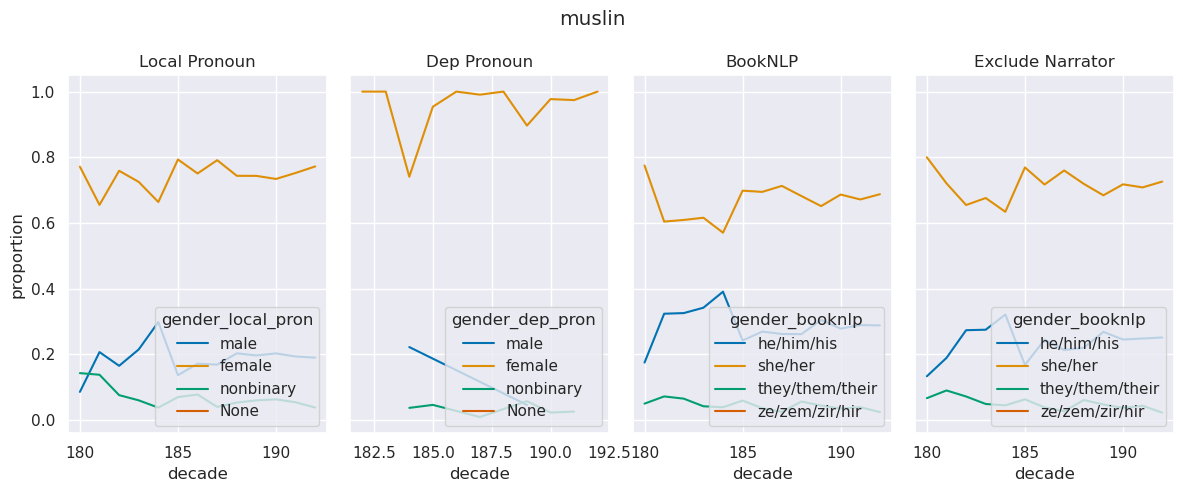

In [146]:
compare_plots("muslin")

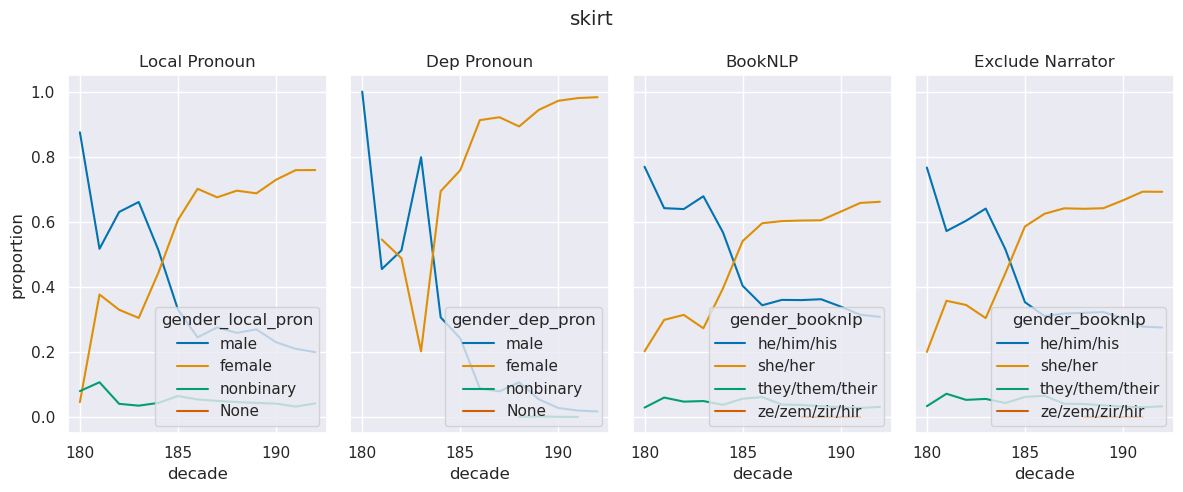

In [147]:
compare_plots("skirt")

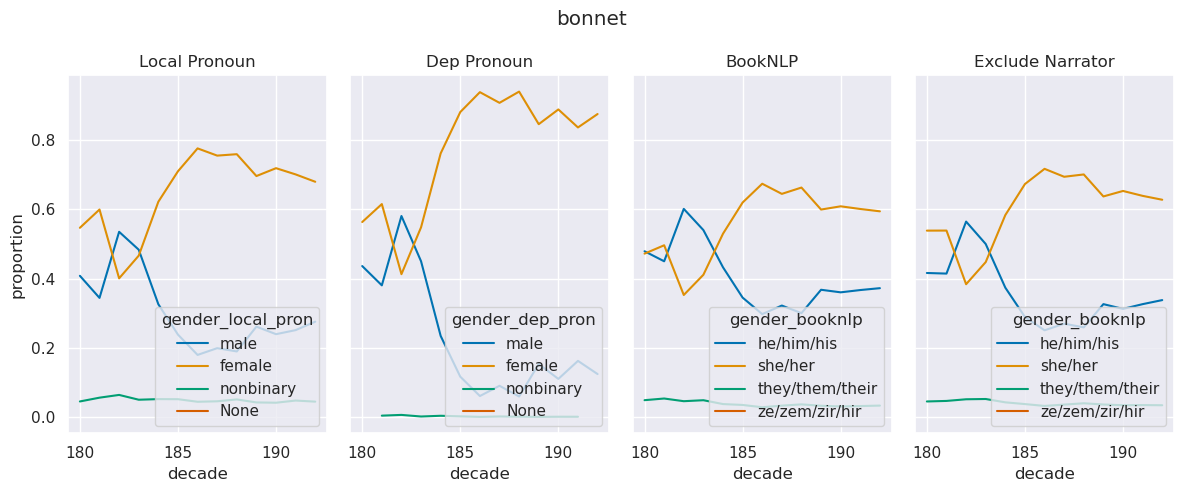

In [148]:
compare_plots("bonnet")

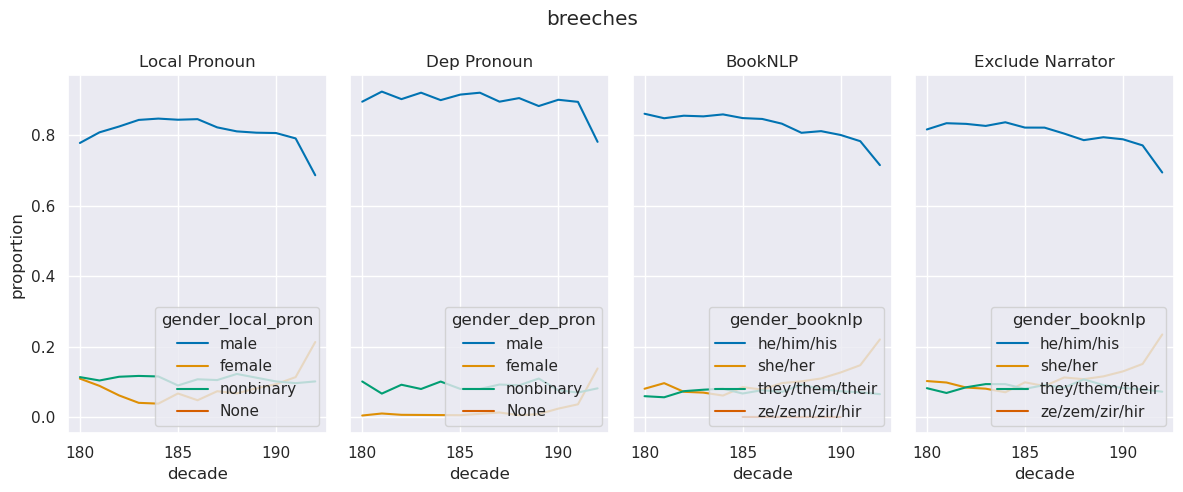

In [149]:
compare_plots("breeches")

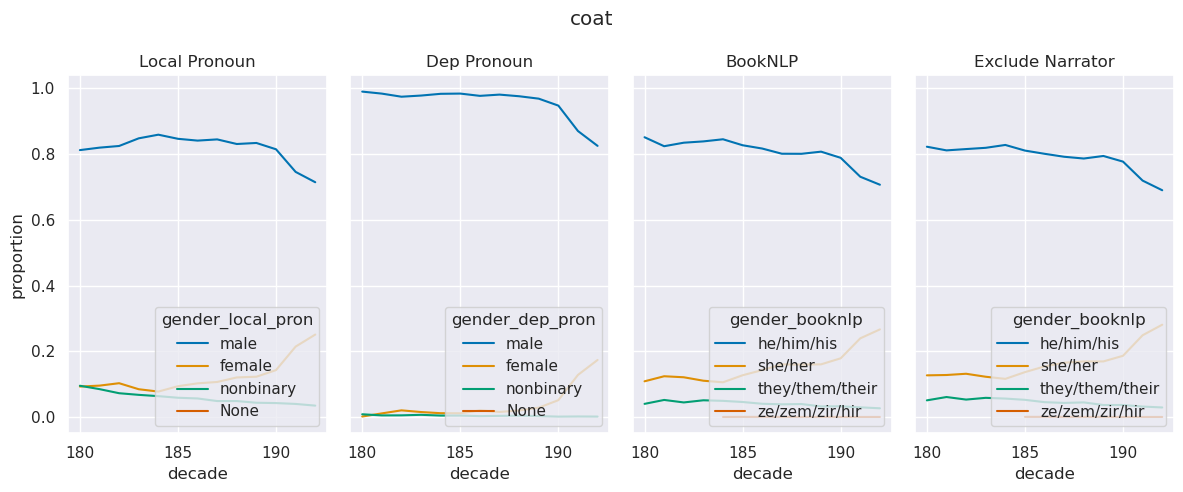

In [150]:
compare_plots("coat")

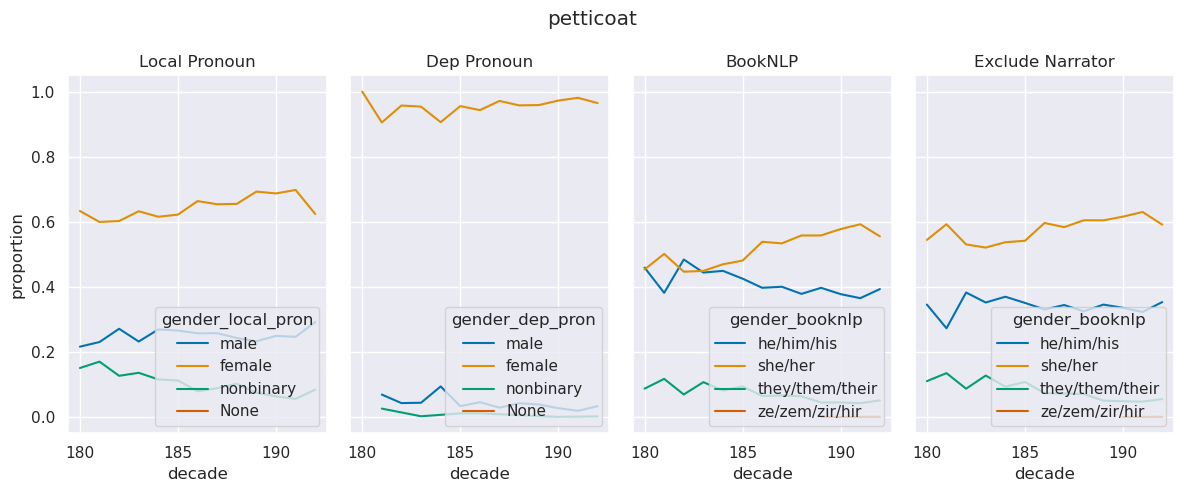

In [151]:
compare_plots("petticoat")

## First order analysis

In [53]:
merged.groupby(level="book_id").decade.first().value_counts().sum()

np.int64(38389)

Text(0.5, 1.0, 'Number of Books per Decade')

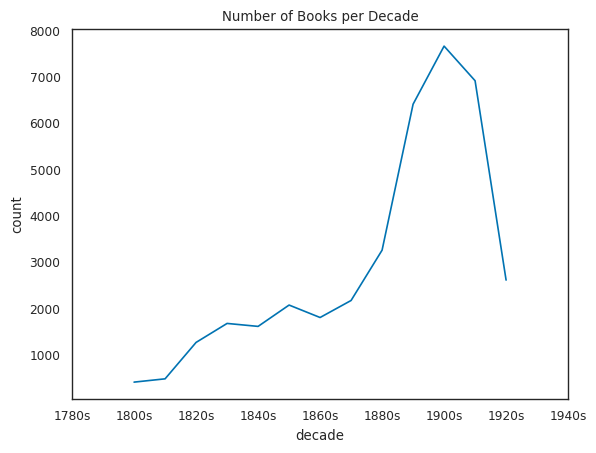

In [401]:
sns.lineplot(
    merged.groupby(level="book_id").decade.first().value_counts().reset_index(),
    x="decade",
    y="count",
)
# format x-axis as decades
plt.xticks(plt.xticks()[0], labels=[f"{int(x*10)}s" for x in plt.xticks()[0]])
plt.title("Number of Books per Decade")

In [20]:
merged.groupby(level="book_id").mention_id.nunique().describe()

count    38390.000000
mean       141.994504
std        140.855132
min          1.000000
25%         56.000000
50%        107.000000
75%        183.000000
max       2701.000000
Name: mention_id, dtype: float64

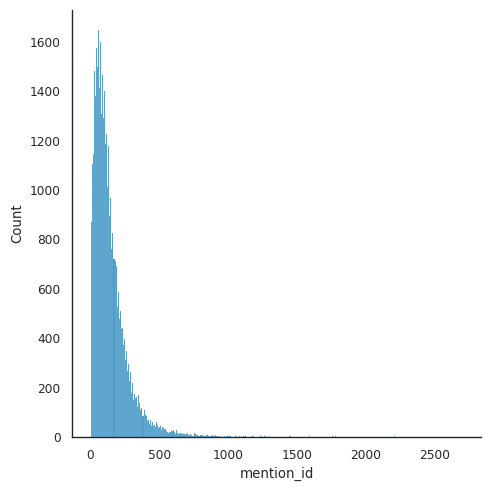

In [ ]:
sns.displot(merged.groupby(level="book_id").mention_id.nunique())

In [392]:
import vl_convert as vlc 

<Axes: title={'center': 'Average Number of Mentions per Book by Decade'}, xlabel='Decade', ylabel='Mentions per Book'>

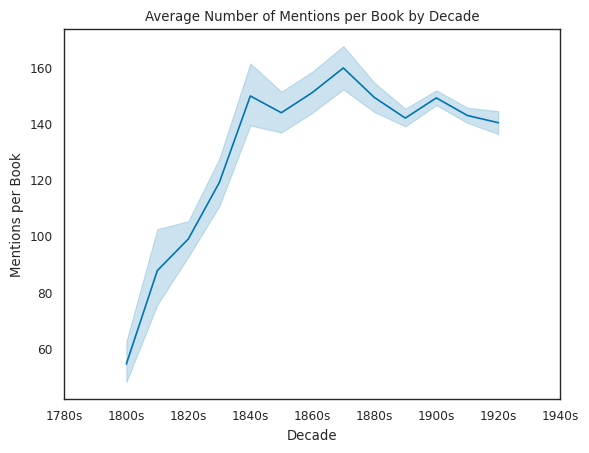

In [404]:
# average number of mentions per book by decade
def _():
    decade_counts = merged.groupby(level="book_id").agg({"mention_id": "nunique", "decade": "first"})
    decade_counts = decade_counts.rename({"mention_id": "avg_mentions"}, axis=1)
    plot = sns.lineplot(decade_counts, x="decade", y="avg_mentions")
    plot.set_title("Average Number of Mentions per Book by Decade")
    plot.set_xlabel("Decade")
    plt.xticks(plt.xticks()[0], labels=[f"{int(x*10)}s" for x in plt.xticks()[0]])
    plot.set_ylabel("Mentions per Book")
    return plot

_()

<Axes: title={'center': 'Average Number of Mentions per Book by Decade (Normalized by Book Length)'}, xlabel='Decade', ylabel='Mentions per Book (Normalized)'>

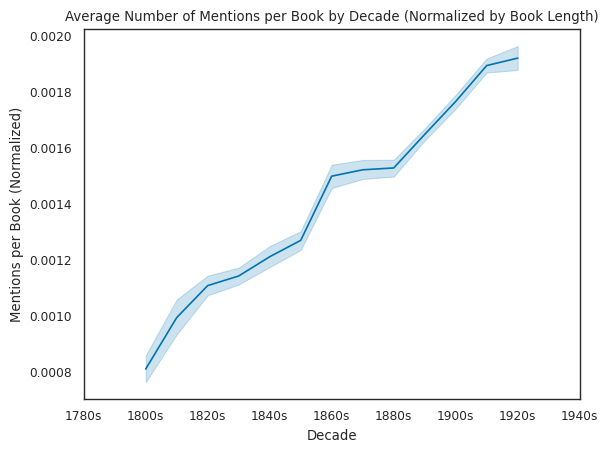

In [405]:
# average number of mentions per book by decade
def _():
    source = HathiAll()
    decade_counts = merged.groupby(level="book_id").agg({"mention_id": "nunique", "decade": "first"})
    decade_counts = decade_counts.rename({"mention_id": "avg_mentions"}, axis=1)

    def _get_full_text_len(book_id):
        text = source.load_text(book_id).text
        return len(text.split())

    decade_counts["full_text_len"] = decade_counts.index.map(_get_full_text_len)
    decade_counts["normalized"] = decade_counts.avg_mentions / decade_counts.full_text_len

    plot = sns.lineplot(decade_counts, x="decade", y="normalized")
    plot.set_title("Average Number of Mentions per Book by Decade (Normalized by Book Length)")
    plt.xticks(plt.xticks()[0], labels=[f"{int(x*10)}s" for x in plt.xticks()[0]])
    plot.set_xlabel("Decade")
    plot.set_ylabel("Mentions per Book (Normalized)")
    return plot

_()

In [72]:
merged.head()

mention_id    term  \
book_id             character_id                       
chi.086202240.clean 0               17370773  shorts   
                    0               17370773  shorts   
                    0               17370773  shorts   
                    0               17370773  shorts   
                    0               17370773  shorts   

                                                                           sentence  \
book_id             character_id                                                      
chi.086202240.clean 0             How long I remained in shorts I cannot novembe...   
                    0             How long I remained in shorts I cannot novembe...   
                    0             How long I remained in shorts I cannot novembe...   
                    0             How long I remained in shorts I cannot novembe...   
                    0             How long I remained in shorts I cannot novembe...   

                                  start_idx  end_idx  sentence_start_idx  \
book_id             character_id                                           
chi.086202240.clean 0                    23       29                4200   
                    0                    23       29                4200   
                    0                    23       29                4200   
                    0                    23       29                4200   
                    0                    23       29                4200   

                                  sentence_end_idx adjectives_fashion  \
book_id             character_id                                        
chi.086202240.clean 0                         4409                 []   
                    0                         4409                 []   
                    0                         4409                 []   
                    0                         4409                 []   
                    0                         4409                 []   

                                  character_start_idx  character_end_idx  \
book_id             character_id                                           
chi.086202240.clean 0                          4230.0             4231.0   
                    0                          4209.0             4210.0   
                    0                          4254.0             4255.0   
                    0                          4154.0             4156.0   
                    0                          4334.0             4336.0   

                                 gender_local_pron all_genders  \
book_id             character_id                                 
chi.086202240.clean 0                         None        None   
                    0                         None        None   
                    0                         None        None   
                    0                         None        None   
                    0                         None        None   

                                 gender_dep_pron  \
book_id             character_id                   
chi.086202240.clean 0                       None   
                    0                       None   
                    0                       None   
                    0                       None   
                    0                       None   

                                                                    adjectives_char  \
book_id             character_id                                                      
chi.086202240.clean 0             [more, content, gay, aged, faithful, astonishe...   
                    0             [more, content, gay, aged, faithful, astonishe...   
                    0             [more, content, gay, aged, faithful, astonishe...   
                    0             [more, content, gay, aged, faithful, astonishe...   
                    0             [more, content, gay, aged, faithful, astonishe...   

               

<Axes: title={'center': 'Average Number of Mentions per Book by Decade (Normalized by Book Length)'}, xlabel='Decade', ylabel='Mentions per Book (Normalized)'>

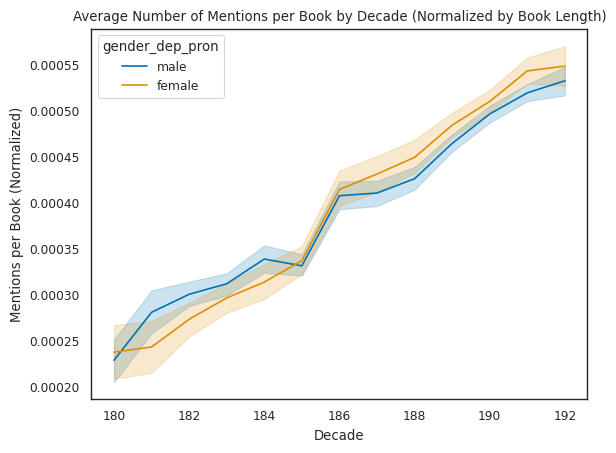

In [78]:
# average number of mentions per book by decade, split by gender
def _():
    source = HathiAll()
    df = merged.dropna(subset=["gender_dep_pron"])
    decade_counts = df.groupby(level="book_id").agg({"mention_id": "nunique", "decade": "first", "gender_dep_pron": "first"})
    decade_counts = decade_counts.rename({"mention_id": "avg_mentions"}, axis=1)

    def _get_full_text_len(book_id):
        text = source.load_text(book_id).text
        return len(text.split())

    decade_counts["full_text_len"] = decade_counts.index.map(_get_full_text_len)
    decade_counts["normalized"] = decade_counts.avg_mentions / decade_counts.full_text_len

    plot = sns.lineplot(decade_counts[decade_counts.gender_dep_pron.isin(["male", "female"])], x="decade", y="normalized", hue="gender_dep_pron")
    plot.set_title("Average Number of Mentions per Book by Decade (Normalized by Book Length)")
    plot.set_xlabel("Decade")
    plot.set_ylabel("Mentions per Book (Normalized)")
    return plot

_()

<Axes: title={'center': 'Average Number of Fashion Adjectives per Fashion Mention by Decade'}, xlabel='Decade', ylabel='Fashion Adjectives per Mention'>

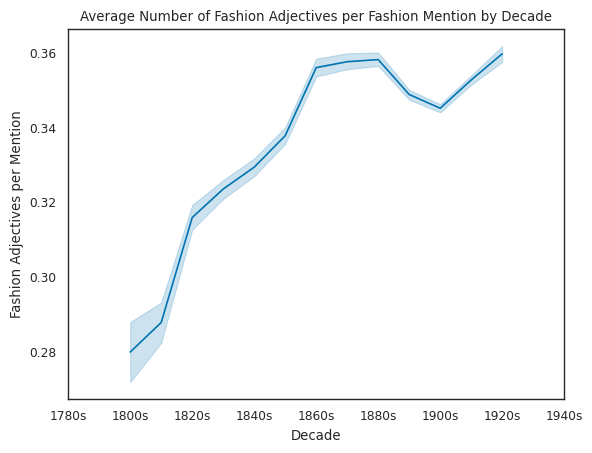

In [407]:
# average number of fashion adjectives per fashion mention by decade
def _():
    unique_mentions = merged.groupby(by=[pd.Grouper(level="book_id"), "mention_id"]).agg({"adjectives_fashion": "first", "decade": "first"})
    unique_mentions["num_adjectives"] = unique_mentions.adjectives_fashion.apply(len)

    plot = sns.lineplot(unique_mentions, x="decade", y="num_adjectives")
    plot.set_title("Average Number of Fashion Adjectives per Fashion Mention by Decade")
    plot.set_xlabel("Decade")
    plot.set_xticks(plot.get_xticks(), labels=[f"{int(x*10)}s" for x in plot.get_xticks()])
    plot.set_ylabel("Fashion Adjectives per Mention")
    return plot

_()

<Axes: title={'center': 'Average Number of Fashion Adjectives per Fashion Mention by Decade (excluding 0-adjective mentions)'}, xlabel='Decade', ylabel='Fashion Adjectives per Mention'>

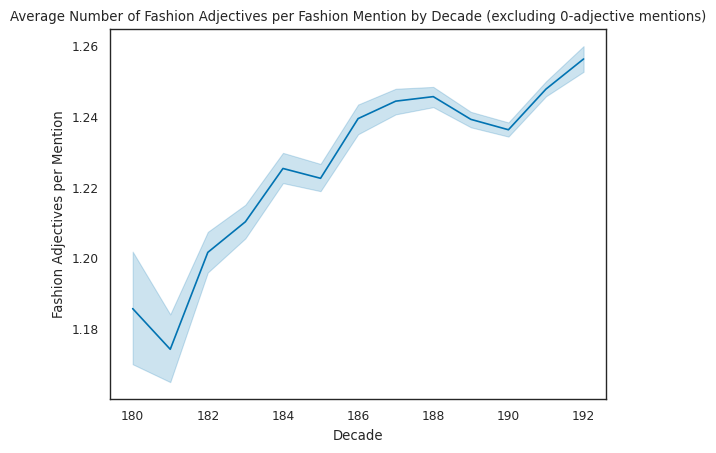

In [69]:
# average number of fashion adjectives per fashion mention by decade
def _():
    unique_mentions = merged.groupby(by=[pd.Grouper(level="book_id"), "mention_id"]).agg({"adjectives_fashion": "first", "decade": "first"})
    unique_mentions["num_adjectives"] = unique_mentions.adjectives_fashion.apply(len)

    plot = sns.lineplot(unique_mentions[unique_mentions.num_adjectives > 0], x="decade", y="num_adjectives")
    plot.set_title("Average Number of Fashion Adjectives per Fashion Mention by Decade (excluding 0-adjective mentions)")
    plot.set_xlabel("Decade")
    plot.set_ylabel("Fashion Adjectives per Mention")
    return plot

_()

<Axes: title={'center': 'Proportion of Fashion Mentions with >0 Adjectives by Decade'}, xlabel='Decade', ylabel='Fashion Adjectives per Mention'>

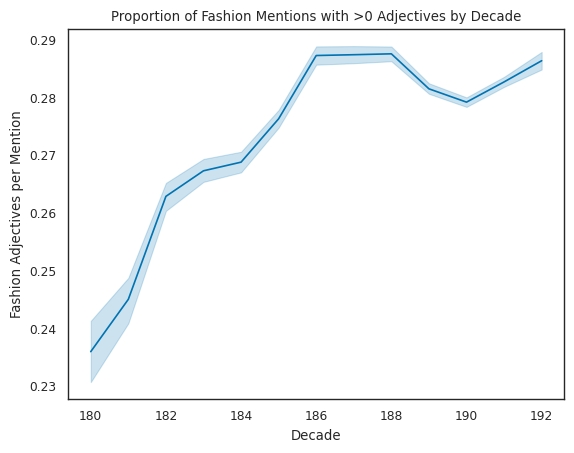

In [71]:
# average number of fashion adjectives per fashion mention by decade
def _():
    unique_mentions = merged.groupby(by=[pd.Grouper(level="book_id"), "mention_id"]).agg({"adjectives_fashion": "first", "decade": "first"})
    unique_mentions["num_adjectives"] = unique_mentions.adjectives_fashion.apply(len)
    unique_mentions["has_adjective"] = unique_mentions.num_adjectives > 0

    plot = sns.lineplot(unique_mentions, x="decade", y="has_adjective")
    plot.set_title("Proportion of Fashion Mentions with >0 Adjectives by Decade")
    plot.set_xlabel("Decade")
    plot.set_ylabel("Fashion Adjectives per Mention")
    return plot

_()

In [56]:
merged.loc["chi.086202240.clean", :].mention_id.nunique()

16

In [ ]:
def _():
    source = HathiAll()
    unique_ids = merged.index.get_level_values("book_id").unique()
    merged.groupby(level="book_id")
    print(len(unique_ids))
    print(len(source.hathi_ids))

_()

38990

## Log Odds

In [79]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
from tqdm import tqdm


@dataclass
class DocTermMatrix:
    mat: np.ndarray
    idx2word: list[str]
    word2idx: dict[str, int]
    idx2doc: list[str]
    doc2idx: dict[str, int]


def create_doc_term_mat(df, document_col, word_col, progress=False):
    idx2word = list(df[word_col].unique())
    word2idx = {v: k for k, v in enumerate(idx2word)}
    idx2doc = list(df[document_col].unique())
    doc2idx = {v: k for k, v in enumerate(idx2doc)}
    mat = np.zeros((len(doc2idx), len(word2idx)))
    for doc, word in tqdm(
        zip(df[document_col], df[word_col]), total=len(df), disable=not progress
    ):
        mat[doc2idx[doc]][word2idx[word]] += 1

    return DocTermMatrix(mat, idx2word, word2idx, idx2doc, doc2idx)


def logodds(matrix, group1, group2=None, min_occurrences=0, zscore=True):
    """
    Compute log odds for one against rest for K documents with N total unique words.

    The prior is computed over all of the words

    Filter out words with less than min_occurrences co-occurrences.
    """
    if not (isinstance(group1, set) or isinstance(group1, list)):
        group1 = set([group1])
    if not (isinstance(group2, set) or isinstance(group2, list)):
        group2 = set([group2])

    mat = matrix.mat.copy()
    mat[mat < min_occurrences] = 0

    _check_group1 = lambda x: x in group1  # noqa
    _check_group2 = (  # noqa
        lambda x: (x in group2) if group2 is not None else (not _check_group1(x))
    )

    def _log_odds_delta(mat, group1_idx, group2_idx, zscore):
        n_prior = mat.sum()
        g_1 = mat[group1_idx].sum(axis=0)
        g_2 = mat[group2_idx].sum(axis=0)
        n_1 = g_1.sum()
        n_2 = g_2.sum()

        prior = mat.sum(axis=0)

        l1 = (g_1 + prior) / ((n_1 + n_prior) - (g_1 + prior))
        l2 = (g_2 + prior) / ((n_2 + n_prior) - (g_2 + prior))
        delta = np.log(l1) - np.log(l2)
        if zscore:
            sigma = np.sqrt(1 / (g_1 + prior) + 1 / (g_2 + prior))
            delta = delta / sigma

        return delta

    group1_idx = [idx for idx, doc in enumerate(matrix.idx2doc) if _check_group1(doc)]
    group2_idx = [idx for idx, doc in enumerate(matrix.idx2doc) if _check_group2(doc)]

    return _log_odds_delta(mat, group1_idx, group2_idx, zscore=zscore)


def write_log_odds(
    matrix: DocTermMatrix,
    output_file: Path,
    group2=None,
    zscore=True,
    threshold=0,
    progress=True,
):
    with open(output_file, "w") as f:
        for c in tqdm(matrix.doc2idx, disable=not progress):
            lor = logodds(matrix, group1=c, group2=group2, zscore=zscore)
            for i in np.argsort(-lor):
                if np.abs(lor[i]) >= threshold:
                    f.write(
                        str(c)
                        + "\t"
                        + str(matrix.idx2word[i])
                        + "\t"
                        + str(lor[i])
                        + "\n"
                    )


def show_log_odds(df, document_col, word_col, group2=None, zscore=True, threshold=2):
    matrix = create_doc_term_mat(df, document_col, word_col)

    for c in matrix.doc2idx:
        lor = logodds(matrix, group1=c, group2=group2, zscore=zscore)
        print(c)
        for i in np.argsort(-np.abs(lor))[:10]:
            if np.abs(lor[i]) >= threshold:
                print("\t" + str(matrix.idx2word[i]) + "\t\t" + str(lor[i]))

In [92]:
# create a document-term matrix where each document is a fashion term and each word is a fashion adjective, and the value is the number of times that adjective co-occurs with that term in a mention 
def _():
    unique_mentions = merged.groupby(by=[pd.Grouper(level="book_id"), "mention_id"]).agg({"adjectives_fashion": "first", "decade": "first", "term": "first"})
    unique_mentions["term"] = unique_mentions.term.str.lower()
    unique_mentions = unique_mentions.explode("adjectives_fashion").dropna()
    unique_mentions["adjectives_fashion"] = unique_mentions.adjectives_fashion.str.lower()
    show_log_odds(unique_mentions.explode("adjectives_fashion").dropna(), "term", "adjectives_fashion", group2=None, zscore=True, threshold=2)

_()

covering
shirt
	clean		12.452886468903671
	open		8.684547732890424
	frilled		4.863791123677891
	collarless		3.9854517486789853
	biled		3.921810651436924
	bloody		3.762790976704229
	dirty		3.2494888909561106
	ruffled		3.168601896464733
	crimean		2.9632640203394987
	black		-2.7719557897472673
dresses
	pretty		4.687667523402003
	many		3.6192450889577197
	gay		3.328274372988435
	new		3.2612641139242187
	beautiful		3.0840236809627446
	such		2.6343644893133886
	fancy		2.325530750282077
	prettiest		2.2842411107692766
	different		2.255254436800131
	necked		2.170922264596227
cotton
	blue		2.984343517210698
	absorbent		2.622151286497315
	white		2.358296986972026
clothing
	warm		4.742707570946846
	dry		3.8860876703574108
	extra		3.3966714323287186
	sufficient		3.187322021769475
	insufficient		3.0510542640532194
	outer		2.9522499108070095
	necessary		2.905350605075096
	scanty		2.8688209414225643
	wet		2.6725351268671234
	secondhand		2.6030165303924977
clothes
	wet		18.426320501682536
	fine		18.087

In [90]:
# create a document-term matrix where each document is a fashion term and each word is a character adjective, and the value is the number of times that adjective co-occurs with that term in a mention 
def _():
    unique_mentions = merged.groupby(by=[pd.Grouper(level="book_id"), "mention_id", "character_id"]).agg({"adjectives_char": "first", "decade": "first", "term": "first"})
    unique_mentions["term"] = unique_mentions.term.str.lower()
    unique_mentions = unique_mentions.explode("adjectives_char").dropna()
    unique_mentions["adjectives_char"] = unique_mentions.adjectives_char.str.lower()
    show_log_odds(unique_mentions, "adjectives_char", "term", group2=None, zscore=True, threshold=2)

_()

more
content
gay
aged
faithful
astonished
determined
	breeches		2.093916022984805
happy
	dress		9.551374608611102
	vestments		-6.244570582872335
	dresses		5.583948894226229
	helmet		-4.323943476062953
	veil		4.302490984600308
	shawl		3.857860094277738
	gown		3.7955479819644093
	belt		-3.7708760066718896
	doublet		-3.5523912708103893
	bonnet		3.509835954911542
certain
	vestments		7.257346576253325
	bands		3.4615369593376526
	cope		2.4371520267008733
	coat		2.221608871066259
	surplice		2.0639974206429486
confluent
glad
	cloak		-8.454364788117578
	mantle		-7.755988696357094
	robe		-7.368075614603576
	hat		7.181435096763741
	girdle		-6.708790542138838
	apparel		-6.6045831443004195
	doublet		-6.134515137589265
	helmet		-5.960443406767613
	clothes		5.555524353776532
	veil		-5.448895196470313
able
	clothes		11.21081854310949
	vestments		11.080634948751925
	clothing		6.834293568792381
	bonnet		-6.576073661708602
	breeches		6.563376889498219
	shawl		-4.438262418104971
	cope		4.35313344318328
	s

KeyboardInterrupt: 

In [91]:
# create a document-term matrix where each document is a fashion term and each word is a character adjective, and the value is the number of times that adjective co-occurs with that term in a mention
def _():
    unique_mentions = merged.groupby(
        by=[pd.Grouper(level="book_id"), "mention_id", "character_id"]
    ).agg({"adjectives_char": "first", "decade": "first", "term": "first"})
    unique_mentions["term"] = unique_mentions.term.str.lower()
    unique_mentions = unique_mentions.explode("adjectives_char").dropna()
    unique_mentions["adjectives_char"] = unique_mentions.adjectives_char.str.lower()
    # only keep terms that occur at least 10 times and adjectives that occur at least 10 times

    n = 10
    unique_terms = unique_mentions.term.value_counts()
    unique_adjectives = unique_mentions.adjectives_char.value_counts()
    unique_mentions = unique_mentions[
        unique_mentions.term.isin(unique_terms[unique_terms >= n].index)
        & unique_mentions.adjectives_char.isin(
            unique_adjectives[unique_adjectives >= n].index
        )
    ]
    show_log_odds(
        unique_mentions,
        "term",
        "adjectives_char",
        group2=None,
        zscore=True,
        threshold=2,
    )


_()

shorts
covering
topcoat
shirt
	old		7.05086789814455
	beautiful		-4.284916648223556
	drunk		3.91332211327808
	dear		-3.894000842754521
	big		3.4288588030559644
	little		-3.4161271200845422
	gwane		3.3202403567969028
	tough		3.0693759534857943
	lovely		-3.0107730465468245
	sweet		-2.9645154439760617
dress
	old		-31.612577140047552
	dear		20.131288718111897
	beautiful		19.229597525389824
	happy		17.932155984988437
	big		-12.645080424768432
	sunny		-11.423942050076068
	drunk		-11.26459985260411
	lovely		10.626479675436503
	hungry		-10.079488043971446
	poor		10.008358325539335
collar
	fat		3.6042315912050644
	old		3.335471649683615
	humble		-3.1503492165162625
	dear		-2.6717853391503423
	pleased		-2.3149662288074486
	obedient		-2.066234143780135
hand
	humble		-4.5007517632006655
	young		4.362921354717546
	obedient		-3.330779014849595
	silent		3.0488886098202217
	sunny		-3.020446548985109
	conscious		2.763733259430439
	ugh		2.6935316943483603
	pleased		-2.58532718357205
	pale		2.57174943416

In [410]:
merged_no_dupe[merged_no_dupe.adjectives_char.apply(lambda x: "sunny" in x if x is not None else False)]

mention_id      term  \
book_id                  character_id                         
coo.31924013536291.clean 166             19401877     plaid   
                         166             19401878   muffler   
                         166             19401885   uniform   
                         166             19401887     plaid   
                         166             19401901      garb   
...                                           ...       ...   
wu.89104490776.clean     107              7226205  cashmere   
                         107              7226206    gloves   
                         107              7226290   clothes   
                         107              7226295     dress   
wu.89104495239.clean     178              7209319  slippers   

                                                                                sentence  \
book_id                  character_id                                                      
coo.31924013536291.clean 166           I wish Norman had been with me, for a that, ” ...   
                         166           I wish Norman had been with me, for a that, ” ...   
                         166           Alice strove to \nanswer with her usual good t...   
                         166           Trembling with cold, Alice drew her plaid more...   
                         166           The guard was being relieved for the night, an...   
...                                                                                  ...   
wu.89104490776.clean     107           “You could wear your blue cashmere, and I will...   
                         107           “You could wear your blue cashmere, and I will...   
                         107           They three sat \nthere in the dark, damp, dism...   
                         107                         She hain't got your dress done." \n   
wu.89104495239.clean     178           Papa had his corner easy chair; his head \nres...   

                                       start_idx  end_idx  sentence_start_idx  \
book_id                  character_id                                           
coo.31924013536291.clean 166                  97      102                8784   
                         166                 103      110                8784   
                         166                 222      229               14835   
                         166                  36       41               16709   
                         166                 147      151               30151   
...                                          ...      ...                 ...   
wu.89104490776.clean     107                  26       34              521208   
                         107                  72       78              521208   
                         107                 201      208              621056   
                         107                  20       25              625183   
wu.89104495239.clean     178                 143      151               54691   

                                       sentence_end_idx adjectives_fashion  \
book_id                  character_id                                        
coo.31924013536291.clean 166                       9157            [large]   
                         166                       9157            [large]   
                         166                      15108                 []   
                         166                      16809                 []   
                         166                      30418             [dark]   
...                                                 ...                ...   
wu.89104490776.clean     107                     521317             [blue]   
                         107                     521317                 []   
                         107                     621288                 []   
                         107                     625217                 []   
wu.89104495239.clean     178    

## Classifier

In [347]:
# construct vocab and indices

genders = []
features = []
decades = []
orig_indices = []
sentences = []

# keep only he/him and she/her (not they/them, which tends to be noisy in our data)
subset = merged.dropna(subset=["gender_dep_pron"])
for row in tqdm(subset.itertuples(), total=len(subset)):
    if row.gender_dep_pron[0] in ("t", "z", "n", "o"):
        continue
    adjs = [adj for adj in row.adjectives_fashion if adj is not None]
    if len(adjs) == 0:
        continue
    decades.append(row.decade)
    genders.append(row.gender_dep_pron)
    row_feats = [f"term_{row.term.lower()}"]
    # row_feats += [adj.lower() for adj in adjs]
    # row_feats += [f"adj_{adj} {row.term}".lower() for adj in adjs]
    features.append(row_feats)
    orig_indices.append(row.Index)
    sentences.append(row.sentence)

100%|███████████████████████████████████████████████████████████████| 5062888/5062888 [00:10<00:00, 462750.72it/s]


In [348]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

encoder = CountVectorizer(
    input="content",
    lowercase=False,
    preprocessor=None,
    tokenizer=lambda x: x,
    min_df=100,
)
encoder.fit(features)

le = LabelEncoder()
le.fit(genders)


def get_features(split):
    split_g = []
    split_f = []
    for i in split:
        split_g.append(genders[i])
        split_f.append(features[i])
    return split_g, split_f


def train_classifier(split):
    genders, features = get_features(split)
    X = encoder.transform(features)
    y = le.transform(genders)
    model = LogisticRegression(penalty="l1", solver="liblinear")
    model.fit(X, y)

    print(f1_score(y[:1000], model.predict(X[:1000])))

    # print(model.score(X[:1000], y[:1000]))
    return model

/data/naitian/fashion/.pixi/envs/default/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [349]:
le.classes_

array(['female', 'male'], dtype='<U6')

In [350]:
len(genders), len(features), len(decades), len(orig_indices)

(950975, 950975, 950975, 950975)

In [351]:
models = []
for decade in range(180, 192):
    print(decade)
    split = np.where(np.array(decades) == decade)[0]
    model = train_classifier(split)
    models.append(model)

180
0.8285504047093452
181
0.8045977011494253
182
0.801423487544484
183
0.8223776223776224
184
0.8373071528751753
185
0.7960363336085879
186
0.7887579329102448
187
0.7608695652173914
188
0.7557117750439367
189
0.6943231441048034
190
0.7614678899082569
191
0.8064257028112449


In [352]:
def _():
    for i, decade in enumerate(range(180, 192)):
        print("======", decade, "=======")
        model = models[i]
        features = encoder.get_feature_names_out()
        k = 10

        print(le.classes_[1])
        for i in model.coef_.argsort()[0, -k:][::-1]:
            print(f"{features[i]}\t{model.coef_[0, i]}")

        print()

        print(le.classes_[0])
        for i in model.coef_.argsort()[0, :k]:
            print(f"{features[i]}\t{model.coef_[0, i]}")


_()

====== 180 =======
male
term_coat	4.163627850397809
term_uniform	2.955896319225057
term_cap	2.6682142467732746
term_breeches	2.405849982305786
term_helmet	2.223528425511827
term_shirt	2.1400667671124243
term_waistcoat	2.095615004541586
term_livery	2.0003848741976187
term_cover	1.894944309079438
term_boots	1.8378659446998422

female
term_apron	-3.767936121596141
term_caps	-3.1925719766925957
term_bonnet	-2.9412575484116847
term_bands	-2.787186918044782
term_pelisse	-2.7871869180447812
term_stays	-2.787186918044781
term_sleeve	-2.787106868584426
term_periwig	-2.6047853117904713
term_liveries	-2.6047853117904696
term_band	-2.3817218099366153
====== 181 =======
male
term_coat	3.486351825385407
term_shirt	3.277922067867344
term_uniform	3.2588223061715706
term_waistcoat	3.1362715508273173
term_breeches	2.8629782158818426
term_bow	2.30336242811187
term_helmet	2.198001912495842
term_accoutrements	2.140843498680273
term_clothing	2.1407919279401963
term_pipe	2.0801673061510133

female
term_veil	

In [353]:
encoder.get_feature_names_out()

array(['term_accoutrement', 'term_accoutrements', 'term_apparel',
       'term_apron', 'term_aprons', 'term_array', 'term_attire',
       'term_bag', 'term_bags', 'term_band', 'term_bands',
       'term_bathrobe', 'term_bead', 'term_beads', 'term_beaver',
       'term_belt', 'term_black', 'term_blouse', 'term_blouses',
       'term_blue', 'term_boa', 'term_bodice', 'term_bonnet',
       'term_bonnets', 'term_boot', 'term_boots', 'term_bow', 'term_bows',
       'term_bracelet', 'term_bracelets', 'term_braces', 'term_braid',
       'term_braids', 'term_breeches', 'term_brocade', 'term_buttonhole',
       'term_caftan', 'term_calash', 'term_cap', 'term_cape',
       'term_capote', 'term_caps', 'term_cashmere', 'term_cassock',
       'term_castor', 'term_change', 'term_chapeau', 'term_chaps',
       'term_chemise', 'term_choker', 'term_cloak', 'term_cloth',
       'term_clothes', 'term_clothing', 'term_coat', 'term_coats',
       'term_coif', 'term_collar', 'term_collars', 'term_corduroys'

In [354]:
# find the highest confidence misclassifications in each decade

from sympy import true


def _():
    for decade in range(180, 192):
        print("======", decade, "=======")
        split = np.where(np.array(decades) == decade)[0]
        model = models[decade - 180]
        features = encoder.get_feature_names_out()
        k = 10
        split_g, split_f = get_features(split)
        X = encoder.transform(split_f)
        y = le.transform(split_g)
        probs = model.predict_proba(X)
        preds = model.predict(X)

        misclassifications = np.where(preds != y)[0]
        true_labels = np.array(split_g)[misclassifications]
        probs = probs[misclassifications]
        original_indices = np.array(split)[misclassifications]
        feats = [split_f[i] for i in misclassifications]
        miss_sentences = np.array(sentences)[split][misclassifications]

        for i in np.argsort(-probs.max(axis=1))[:k]:
            print(f"Gender: {true_labels[i]}")
            print(f"Original Index: {original_indices[i]}")
            print(f"Sentence: {miss_sentences[i]}")
            print(f"{feats[i]}")
            print(f"{[model.coef_[0, np.where(np.array(encoder.transform([[feat]]).todense())[0])] for feat in feats[i]]}")
            print(f"Predicted: {le.classes_[preds[misclassifications][i]]}")
            print(f"Probabilities: {probs[i]}")
            print()
_()

====== 180 =======
Gender: female
Original Index: 154003
Sentence: her purple jane shoes peeping significantly 
under the half seen dimity petti 
coat, and forcing on the sight of the 
company the instep brilliancy of a mock 
diamond in the centre of a rose knot. 

['term_shoes']
[array([[1.40246782]])]
Predicted: male
Probabilities: [0.08333333 0.91666667]

Gender: female
Original Index: 468434
Sentence: This the duke
granted, much wondering at the youthful appearance 
of the stranger, who was prettily disguised 
by her counsellor's robes and her large wig. 

['term_wig']
[array([[1.35594781]])]
Predicted: male
Probabilities: [0.08695652 0.91304348]

Gender: female
Original Index: 468432
Sentence: This the duke
granted, much wondering at the youthful appearance 
of the stranger, who was prettily disguised 
by her counsellor's robes and her large wig. 

['term_wig']
[array([[1.35594781]])]
Predicted: male
Probabilities: [0.08695652 0.91304348]

Gender: female
Original Index: 468433
Sen

In [355]:
# get the top 5 and bottom 5 features for each gender for each decade
# and plot them over time

m_terms = set()
f_terms = set()

for i, decade in enumerate(range(180, 192)):
    model = models[i]
    features = encoder.get_feature_names_out()
    m_terms.update(features[model.coef_.argsort()[0, -5:]])
    f_terms.update(features[model.coef_.argsort()[0, :5]])


m_term_weights: list[dict[str, float]] = []
f_term_weights: list[dict[str, float]] = []

for i, decade in enumerate(range(180, 192)):
    model = models[i]
    features = encoder.get_feature_names_out()
    feature_indices = {features[j]: j for j in range(len(features))}
    m_term_weights.append(
        {
            feature_name: model.coef_[0, feature_indices[feature_name]]
            for feature_name in m_terms
        }
    )
    f_term_weights.append(
        {
            feature_name: model.coef_[0, feature_indices[feature_name]]
            for feature_name in f_terms
        }
    )


In [ ]:
# plot each of these terms over time

import altair as alt

decades = list(range(180, 192))

# Prepare data for plotting
m_plot_data = []
f_plot_data = []

for decade_idx, decade in enumerate(decades):
    for term in m_terms:
        weight = m_term_weights[decade_idx].get(term, 0)
        m_plot_data.append(
            {"decade": decade, "term": term.replace("term_", ""), "weight": weight}
        )

    for term in f_terms:
        weight = f_term_weights[decade_idx].get(term, 0)
        f_plot_data.append(
            {"decade": decade, "term": term.replace("term_", ""), "weight": weight}
        )

m_df = pd.DataFrame(m_plot_data)
f_df = pd.DataFrame(f_plot_data)

# Create selection for interactive legend and clickable lines
m_selection = alt.selection_point(
    fields=["term"],
    bind="legend",
    on="click",
    nearest=True,
    resolve="global",
    name="Male Terms",
)
f_selection = alt.selection_point(
    fields=["term"],
    bind="legend",
    on="click",
    nearest=True,
    resolve="global",
    name="Female Terms",
)

# Create male-associated terms chart
m_chart = (
    alt.Chart(m_df)
    .mark_line(point=True)
    .encode(
        x=alt.X("decade:O", title="Decade", scale=alt.Scale(domain=decades)),
        y=alt.Y("weight:Q", title="Model Weight"),
        color=alt.Color("term:N", title="Term"),
        opacity=alt.condition(m_selection, alt.value(1), alt.value(0.2)),
        tooltip=["decade:O", "term:N", "weight:Q"],
    )
    .add_params(m_selection)
    .properties(width=600, height=400, title="Male-Associated Terms Over Time")
)

# Create female-associated terms chart
f_chart = (
    alt.Chart(f_df)
    .mark_line(point=True)
    .encode(
        x=alt.X("decade:O", title="Decade", scale=alt.Scale(domain=decades)),
        y=alt.Y("weight:Q", title="Model Weight"),
        color=alt.Color("term:N", title="Term"),
        opacity=alt.condition(f_selection, alt.value(1), alt.value(0.2)),
        tooltip=["decade:O", "term:N", "weight:Q"],
    )
    .add_params(f_selection)
    .properties(width=600, height=400, title="Female-Associated Terms Over Time")
)

# Combine charts side by side
(m_chart | f_chart).resolve_scale(color="independent")


alt.HConcatChart(...)

## Prevalence

In [7]:
merged_no_dupe = (
    merged.reset_index()
    .drop_duplicates(subset=["book_id", "mention_id"])
    .set_index(["book_id", "character_id"])
)

In [412]:
# Instead of plotting the model weights, plot the prevalence (counts) of each term over time,
# and add binomial MLE confidence intervals for each estimated prevalence.
def _(merged_no_dupe):
    import numpy as np
    from scipy.stats import norm

    decades = list(range(180, 192))

    prevalence_df = merged_no_dupe.drop_duplicates(subset=["mention_id", "sentence"])
    prevalence_df.term = prevalence_df.term.str.lower()
    prevalence_df = (
        prevalence_df.groupby(["decade", "term"]).size().reset_index(name="count")
    )
    prevalence_df["decade_label"] = prevalence_df.decade.apply(lambda x: f"{int(x*10)}s")

    # Binomial MLE-based normal approximation 95% confidence interval for a proportion
    def binom_ci(k, n, conf=0.95):
        # k = count of instances of term
        # n = total number of mentions for the decade
        # p = k/n
        # For normal approx: p ± z * sqrt(p*(1-p)/n)
        p = k / n if n > 0 else 0.0
        z = norm.ppf(1 - (1 - conf) / 2)
        stderr = np.sqrt(p * (1 - p) / n) if n > 0 else 0.0
        lower = max(0, p - z * stderr)
        upper = min(1, p + z * stderr)
        return lower, upper

    m_selection = alt.selection_point(
        fields=["term"],
        bind="legend",
        on="click",
        nearest=True,
        resolve="global",
        name="Male Terms",
    )
    f_selection = alt.selection_point(
        fields=["term"],
        bind="legend",
        on="click",
        nearest=True,
        resolve="global",
        name="Female Terms",
    )

    # Filter to decades of interest
    prevalence_df = prevalence_df[
        prevalence_df.decade.ge(180) & prevalence_df.decade.le(192)
    ]

    # Compute the total number of term mentions ("n") per decade
    prevalence_df["total_mentions"] = prevalence_df.groupby("decade")[
        "count"
    ].transform(lambda x: x.sum())

    # Prevalence (proportion)
    prevalence_df["count_norm"] = (
        prevalence_df["count"] / prevalence_df["total_mentions"]
    )

    # Calculate binomial confidence intervals for each row
    ci = prevalence_df.apply(
        lambda row: binom_ci(row["count"], row["total_mentions"]), axis=1
    )
    prevalence_df["ci_low"] = [v[0] for v in ci]
    prevalence_df["ci_high"] = [v[1] for v in ci]

    # Select terms for male and female associations
    m_terms_stripped = [term[5:] for term in m_terms]
    f_terms_stripped = [term[5:] for term in f_terms]

    m_term_counts = prevalence_df[prevalence_df.term.isin(m_terms_stripped)]
    f_term_counts = prevalence_df[prevalence_df.term.isin(f_terms_stripped)]

    # add brush selection for the y-axis
    y_scale_brush = alt.selection_interval(encodings=["y"])

    # Plot: point+line for prevalence, band for confidence interval
    m_count_chart = (
        alt.Chart(m_term_counts)
        .mark_line(point=True)
        .encode(
            x=alt.X("decade_label:O", title="Decade", sort=decades),
            y=alt.Y("count_norm:Q", title="Prevalence (Count)"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(m_selection, alt.value(1), alt.value(0.2)),
            tooltip=["decade_label:O", "term:N", "count_norm:Q", "ci_low:Q", "ci_high:Q"],
        )
        .add_params(m_selection, y_scale_brush)
        .properties(
            width=600, height=400, title="Male-Associated Term Prevalence Over Time"
        )
    )

    m_band = (
        alt.Chart(m_term_counts)
        .mark_area(opacity=0.2)
        .encode(
            x=alt.X("decade_label:O", title="Decade", sort=decades),
            y=alt.Y("ci_low:Q", title="95% CI Lower"),
            y2=alt.Y2("ci_high:Q", title="95% CI Upper"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(m_selection, alt.value(0.4), alt.value(0.1)),
        )
    )
    m_chart = m_band + m_count_chart

    f_count_chart = (
        alt.Chart(f_term_counts)
        .mark_line(point=True)
        .encode(
            x=alt.X("decade_label:O", title="Decade", sort=decades),
            y=alt.Y("count_norm:Q", title="Prevalence (Count)"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(f_selection, alt.value(1), alt.value(0.2)),
            tooltip=["decade_label:O", "term:N", "count_norm:Q", "ci_low:Q", "ci_high:Q"],
        )
        .add_params(f_selection)
        .properties(
            width=600, height=400, title="Female-Associated Term Prevalence Over Time"
        )
    )

    f_band = (
        alt.Chart(f_term_counts)
        .mark_area(opacity=0.2)
        .encode(
            x=alt.X("decade_label:O", title="Decade", sort=decades),
            y=alt.Y("ci_low:Q", title="95% CI Lower"),
            y2=alt.Y2("ci_high:Q", title="95% CI Upper"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(f_selection, alt.value(0.4), alt.value(0.1)),
        )
    )

    f_chart = f_band + f_count_chart

    return (m_chart | f_chart).resolve_scale(color="independent")


_(merged_no_dupe)

alt.HConcatChart(...)

In [ ]:
# sample one mention from each book
# Instead of plotting the model weights, plot the prevalence (counts) of each term over time,
# and add binomial MLE confidence intervals for each estimated prevalence.
def _(merged_no_dupe):
    import numpy as np
    from scipy.stats import norm

    decades = list(range(180, 192))

    prevalence_df = merged_no_dupe.groupby(["book_id", "term"]).first().reset_index()
    prevalence_df.term = prevalence_df.term.str.lower()
    prevalence_df = (
        prevalence_df.groupby(["decade", "term"]).size().reset_index(name="count")
    )

    # Binomial MLE-based normal approximation 95% confidence interval for a proportion
    def binom_ci(k, n, conf=0.95):
        # k = count of instances of term
        # n = total number of mentions for the decade
        # p = k/n
        # For normal approx: p ± z * sqrt(p*(1-p)/n)
        p = k / n if n > 0 else 0.0
        z = norm.ppf(1 - (1 - conf) / 2)
        stderr = np.sqrt(p * (1 - p) / n) if n > 0 else 0.0
        lower = max(0, p - z * stderr)
        upper = min(1, p + z * stderr)
        return lower, upper

    m_selection = alt.selection_point(
        fields=["term"],
        bind="legend",
        on="click",
        nearest=True,
        resolve="global",
        name="Male Terms",
    )
    f_selection = alt.selection_point(
        fields=["term"],
        bind="legend",
        on="click",
        nearest=True,
        resolve="global",
        name="Female Terms",
    )

    # Filter to decades of interest
    prevalence_df = prevalence_df[
        prevalence_df.decade.ge(180) & prevalence_df.decade.le(192)
    ]

    # Compute the total number of term mentions ("n") per decade
    prevalence_df["total_mentions"] = prevalence_df.groupby("decade")[
        "count"
    ].transform(lambda x: x.sum())

    # Prevalence (proportion)
    prevalence_df["count_norm"] = (
        prevalence_df["count"] / prevalence_df["total_mentions"]
    )

    # Calculate binomial confidence intervals for each row
    ci = prevalence_df.apply(
        lambda row: binom_ci(row["count"], row["total_mentions"]), axis=1
    )
    prevalence_df["ci_low"] = [v[0] for v in ci]
    prevalence_df["ci_high"] = [v[1] for v in ci]

    # Select terms for male and female associations
    m_terms_stripped = [term[5:] for term in m_terms]
    f_terms_stripped = [term[5:] for term in f_terms]

    m_term_counts = prevalence_df[prevalence_df.term.isin(m_terms_stripped)]
    f_term_counts = prevalence_df[prevalence_df.term.isin(f_terms_stripped)]

    # add brush selection for the y-axis
    y_scale_brush = alt.selection_interval(encodings=["y"])

    # Plot: point+line for prevalence, band for confidence interval
    m_count_chart = (
        alt.Chart(m_term_counts)
        .mark_line(point=True)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("count_norm:Q", title="Prevalence (Count)"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(m_selection, alt.value(1), alt.value(0.2)),
            tooltip=["decade:O", "term:N", "count_norm:Q", "ci_low:Q", "ci_high:Q"],
        )
        .add_params(m_selection, y_scale_brush)
        .properties(
            width=600, height=400, title="Male-Associated Term Prevalence Over Time"
        )
    )

    m_band = (
        alt.Chart(m_term_counts)
        .mark_area(opacity=0.2)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("ci_low:Q", title="95% CI Lower"),
            y2=alt.Y2("ci_high:Q", title="95% CI Upper"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(m_selection, alt.value(0.4), alt.value(0.1)),
        )
    )
    m_chart = m_band + m_count_chart

    f_count_chart = (
        alt.Chart(f_term_counts)
        .mark_line(point=True)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("count_norm:Q", title="Prevalence (Count)"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(f_selection, alt.value(1), alt.value(0.2)),
            tooltip=["decade:O", "term:N", "count_norm:Q", "ci_low:Q", "ci_high:Q"],
        )
        .add_params(f_selection)
        .properties(
            width=600, height=400, title="Female-Associated Term Prevalence Over Time"
        )
    )

    f_band = (
        alt.Chart(f_term_counts)
        .mark_area(opacity=0.2)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("ci_low:Q", title="95% CI Lower"),
            y2=alt.Y2("ci_high:Q", title="95% CI Upper"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(f_selection, alt.value(0.4), alt.value(0.1)),
        )
    )

    f_chart = f_band + f_count_chart

    return (
        (m_chart | f_chart)
        .resolve_scale(color="independent")
        .properties(
            title="Prevalence of terms, sampling max one mention per term per book"
        )
    )


_(merged_no_dupe)

alt.HConcatChart(...)

## Adjectives

There are multiple ways to think about prevalence of description. For instance:
1. How many times is something described as black over all the ways something is described (#black / #present adjectives)
2. How many times is something described as black over all the colors something is described as (#black / #colors)
3. How many times is something described as black over all the instances in which something can be described (#black / #mentions)


We will start with last method.

In [328]:
# sample one mention from each book
# Instead of plotting the model weights, plot the prevalence (counts) of each term over time,
# and add binomial MLE confidence intervals for each estimated prevalence.
def _(merged_no_dupe, term="coat"):
    decades = list(range(180, 192))

    prevalence_df = merged_no_dupe.groupby(["book_id", "term"]).first().reset_index()
    prevalence_df.term = prevalence_df.term.str.lower()
    prevalence_df = prevalence_df.explode("adjectives_fashion")
    prevalence_df = (
        prevalence_df.groupby(["decade", "term", "adjectives_fashion"])
        .size()
        .reset_index(name="count")
    )

    # Binomial MLE-based normal approximation 95% confidence interval for a proportion
    def binom_ci(k, n, conf=0.95):
        # k = count of instances of term
        # n = total number of mentions for the decade
        # p = k/n
        # For normal approx: p ± z * sqrt(p*(1-p)/n)
        p = k / n if n > 0 else 0.0
        z = norm.ppf(1 - (1 - conf) / 2)
        stderr = np.sqrt(p * (1 - p) / n) if n > 0 else 0.0
        lower = max(0, p - z * stderr)
        upper = min(1, p + z * stderr)
        return lower, upper

    m_selection = alt.selection_point(
        fields=["term"],
        bind="legend",
        on="click",
        nearest=True,
        resolve="global",
        name="Male Terms",
    )
    f_selection = alt.selection_point(
        fields=["term"],
        bind="legend",
        on="click",
        nearest=True,
        resolve="global",
        name="Female Terms",
    )

    # Filter to decades of interest
    prevalence_df = prevalence_df[
        prevalence_df.decade.ge(180) & prevalence_df.decade.le(192)
    ]

    decade_mention_counts = (
        prevalence_df.groupby(["decade", "term"])
        .mention_id.nunique()
        .reset_index(name="term_mention_count")
    )
    prevalence_df = prevalence_df.merge(decade_mention_counts, on=["decade", "term"])
    # Compute the total number of term mentions ("n") per decade

    # Prevalence (proportion)
    prevalence_df["count_norm"] = (
        prevalence_df["count"] / prevalence_df["term_mention_count"]
    )

    # Calculate binomial confidence intervals for each row
    ci = prevalence_df.apply(
        lambda row: binom_ci(row["count"], row["term_mention_count"]), axis=1
    )
    prevalence_df["ci_low"] = [v[0] for v in ci]
    prevalence_df["ci_high"] = [v[1] for v in ci]

    # Select terms for male and female associations
    m_terms_stripped = [term[5:] for term in m_terms]
    f_terms_stripped = [term[5:] for term in f_terms]

    m_term_counts = prevalence_df[prevalence_df.term.eq(term)]
    top_adjectives = m_term_counts.adjectives_fashion.value_counts().head(10).index
    m_term_counts = m_term_counts[m_term_counts.adjectives_fashion.isin(top_adjectives)]
    # f_term_counts = prevalence_df[prevalence_df.term.isin(f_terms_stripped)]

    # add brush selection for the y-axis
    y_scale_brush = alt.selection_interval(encodings=["y"])

    # Plot: point+line for prevalence, band for confidence interval
    m_count_chart = (
        alt.Chart(m_term_counts)
        .mark_line(point=True)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("count_norm:Q", title="Prevalence (Count)"),
            color=alt.Color("adjectives_fashion:N", title="Term"),
            opacity=alt.condition(m_selection, alt.value(1), alt.value(0.2)),
            tooltip=["decade:O", "term:N", "count_norm:Q", "ci_low:Q", "ci_high:Q"],
        )
        .add_params(m_selection, y_scale_brush)
        .properties(
            width=600, height=400, title=f"Adjectives for {term} Prevalence Over Time"
        )
    )

    m_band = (
        alt.Chart(m_term_counts)
        .mark_area(opacity=0.2)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("ci_low:Q", title="95% CI Lower"),
            y2=alt.Y2("ci_high:Q", title="95% CI Upper"),
            color=alt.Color("adjectives_fashion:N", title="Term"),
            opacity=alt.condition(m_selection, alt.value(0.4), alt.value(0.1)),
        )
    )
    m_chart = m_band + m_count_chart
    return m_chart

    f_count_chart = (
        alt.Chart(f_term_counts)
        .mark_line(point=True)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("count_norm:Q", title="Prevalence (Count)"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(f_selection, alt.value(1), alt.value(0.2)),
            tooltip=["decade:O", "term:N", "count_norm:Q", "ci_low:Q", "ci_high:Q"],
        )
        .add_params(f_selection)
        .properties(
            width=600, height=400, title="Female-Associated Term Prevalence Over Time"
        )
    )

    f_band = (
        alt.Chart(f_term_counts)
        .mark_area(opacity=0.2)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("ci_low:Q", title="95% CI Lower"),
            y2=alt.Y2("ci_high:Q", title="95% CI Upper"),
            color=alt.Color("term:N", title="Term"),
            opacity=alt.condition(f_selection, alt.value(0.4), alt.value(0.1)),
        )
    )

    f_chart = f_band + f_count_chart

    return (
        (m_chart | f_chart)
        .resolve_scale(color="independent")
        .properties(
            title="Prevalence of terms, sampling max one mention per term per book"
        )
    )


_(merged_no_dupe.sample(1000))

AttributeError: 'DataFrameGroupBy' object has no attribute 'mention_id'

## Adjective categories

In [183]:
from nltk.corpus import wordnet as wn
from nltk.corpus.reader.wordnet import Synset

In [184]:
def get_attribute_categories(
    term: str | None = None, synset: Synset | None = None
) -> list[Synset]:
    if synset is None:
        synsets: list[Synset | None] = wn.synsets(term, pos="a")
    else:
        synsets = [synset]
    attributes = []
    for synset in synsets:
        if synset is None:
            continue
        if synset.attributes():
            attributes.extend(synset.attributes())
        elif synset.similar_tos():
            for similar_to in synset.similar_tos():
                if similar_to.attributes():
                    attributes.extend(similar_to.attributes())
    return attributes

In [290]:
import itertools

colors = set(
    itertools.chain.from_iterable(
        [
            [lemma.name() for lemma in word.lemmas()]
            for word in wn.synset("chromatic.a.03").similar_tos()
            + wn.synset("achromatic.a.01").similar_tos()
            + wn.synset("value.n.04").attributes()
        ]
    )
)

In [327]:
# find all occurrences of colors as fashion adjectives


def _(df):
    merged_inds = []
    coocs = np.zeros((len(colors), len(colors)))
    color2idx = {color: idx for idx, color in enumerate(colors)}
    idx2color = {idx: color for color, idx in color2idx.items()}
    for i, row in enumerate(tqdm(df.itertuples())):
        adjs = [
            adj.lower()
            for adj in row.adjectives_fashion
            if adj is not None and adj in colors
        ]
        if adjs:
            # for each adjective, cycle thru the words in the sentence and add a cooc for any color words
            sentence_colors = [word for word in row.sentence.split() if word.lower() in colors]
            for adj in adjs:
                for word in sentence_colors:
                    if word.lower() in adjs and word.lower() != adj:
                        continue
                    coocs[color2idx[adj], color2idx[word.lower()]] += 1
            

    # get the index for black
    color_cooc_counts = coocs.sum(axis=0)
    diag = np.eye(len(colors))
    other_coocs = coocs * (1 - diag)
    other_coocs_counts = other_coocs.sum(axis=0)
    self_coocs = coocs * diag

    def categorical_entropy(probs):
        return -np.sum(probs * np.log(probs + 1e-10), axis=-1)

    self_coocs_counts = self_coocs.sum(axis=0)

    entropies = categorical_entropy(coocs / coocs.sum(axis=-1, keepdims=True))
    ratio = other_coocs_counts / color_cooc_counts
    color_inds = np.where(color_cooc_counts > 10000)[0]
    subset_ind_mapping = {orig_idx: subset_idx for subset_idx, orig_idx in enumerate(merged_inds)}


    # print(f"Total co-occurrences involving 'black': {other_coocs_counts[black_idx]}")
    # print(
    #     f"Avg co-occurrences: {other_coocs_counts[np.where(color_cooc_counts > 100)].mean()}"
    # )

    print("Ratios")
    print(
        f"Total co-occurrences involving 'black': {ratio[color2idx['black']]}"
    )
    print(
        f"Avg co-occurrences: {ratio[color_inds].mean()}"
    )
    # plot = sns.displot(other_coocs_counts[np.where(color_cooc_counts > 100)], bins=30)

    # print top colors with coocs
    for color_idx in np.argsort(-ratio[color_inds])[:25]:
        color = idx2color[int(color_inds[color_idx])]
        print(f"{color}: {other_coocs_counts[color_inds[color_idx]]} co-occurrences ({color_cooc_counts[color_inds[color_idx]]} total mentions, ratio {other_coocs_counts[color_inds[color_idx]] / color_cooc_counts[color_inds[color_idx]]:.4f})")

    print()
    print(entropies[color2idx["black"]])
    for color_idx in np.argsort(-entropies[color_inds])[:25]:
        color = idx2color[int(color_inds[color_idx])]
        print(f"{color}: {other_coocs_counts[color_inds[color_idx]]} co-occurrences ({color_cooc_counts[color_inds[color_idx]]} total mentions, entropy {entropies[color_inds[color_idx]]:.4f})")

#     return plot

#     # return df.iloc[merged_inds], coocs, color2idx


_(merged_no_dupe)

5451169it [00:13, 419208.31it/s]

Ratios
Total co-occurrences involving 'black': 0.21835627921154238
Avg co-occurrences: 0.43012091574177974
gold: 20601.0 co-occurrences (20601.0 total mentions, ratio 1.0000)
light: 13559.0 co-occurrences (17542.0 total mentions, ratio 0.7729)
silver: 11998.0 co-occurrences (19424.0 total mentions, ratio 0.6177)
golden: 6218.0 co-occurrences (12339.0 total mentions, ratio 0.5039)
grey: 17340.0 co-occurrences (40569.0 total mentions, ratio 0.4274)
dark: 13733.0 co-occurrences (32820.0 total mentions, ratio 0.4184)
yellow: 10532.0 co-occurrences (25242.0 total mentions, ratio 0.4172)
brown: 12065.0 co-occurrences (33831.0 total mentions, ratio 0.3566)
pink: 7345.0 co-occurrences (21013.0 total mentions, ratio 0.3495)
green: 12405.0 co-occurrences (37381.0 total mentions, ratio 0.3319)
scarlet: 5968.0 co-occurrences (18477.0 total mentions, ratio 0.3230)
red: 22387.0 co-occurrences (70282.0 total mentions, ratio 0.3185)
purple: 3116.0 co-occurrences (10732.0 total mentions, ratio 0.2903)



/tmp/ipykernel_1359488/1655314536.py:37: RuntimeWarning: invalid value encountered in divide
  entropies = categorical_entropy(coocs / coocs.sum(axis=-1, keepdims=True))
/tmp/ipykernel_1359488/1655314536.py:38: RuntimeWarning: invalid value encountered in divide
  ratio = other_coocs_counts / color_cooc_counts


In [ ]:
# for a given term, identify all instances where it is described with a color;
# over the decades, plot the relative prevalence of different colors used to
# describe that term, with confidence intervals for the proportions in each
# decade.
from scipy.stats import norm


def visualize_color_distribution(merged_no_dupe, terms=["coat"], title=None):
    decades = list(range(180, 192))
        
    # Filter data for the given term
    term_df = merged_no_dupe[merged_no_dupe.term.isin(terms) & merged_no_dupe.decade.isin(decades)].copy()
    
    # Explode adjectives_fashion to get one row per adjective
    term_df = term_df.explode("adjectives_fashion")
    
    # Filter to only color adjectives
    term_df = term_df[term_df.adjectives_fashion.str.lower().isin(colors)]
    
    # Group by decade and color, count occurrences
    color_counts = term_df.groupby(["decade", "adjectives_fashion"]).size().reset_index(name="count")
    
    # Get total mentions per decade for this term
    decade_totals = merged_no_dupe[merged_no_dupe.term.isin(terms) & merged_no_dupe.decade.isin(decades)].groupby("decade").size().reset_index(name="total")
    
    # Merge to get proportions
    color_counts = color_counts.merge(decade_totals, on="decade")
    color_counts["proportion"] = color_counts["count"] / color_counts["total"]
    
    # Binomial confidence intervals
    def binom_ci(k, n, conf=0.95):
        p = k / n if n > 0 else 0.0
        z = norm.ppf(1 - (1 - conf) / 2)
        stderr = np.sqrt(p * (1 - p) / n) if n > 0 else 0.0
        lower = max(0, p - z * stderr)
        upper = min(1, p + z * stderr)
        return lower, upper
    
    ci = color_counts.apply(lambda row: binom_ci(row["count"], row["total"]), axis=1)
    color_counts["ci_low"] = [v[0] for v in ci]
    color_counts["ci_high"] = [v[1] for v in ci]
    
    # Get top colors overall
    top_colors = color_counts.groupby("adjectives_fashion")["count"].sum().nlargest(10).index
    color_counts = color_counts[color_counts.adjectives_fashion.isin(top_colors)]
    
    # Create selection
    color_selection = alt.selection_point(
        fields=["adjectives_fashion"],
        bind="legend",
        on="click",
        nearest=True,
        resolve="global"
    )
    
    title = ", ".join(terms) if title is None else title
    # Create line chart
    line_chart = (
        alt.Chart(color_counts)
        .mark_line(point=True)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("proportion:Q", title="Proportion"),
            color=alt.Color("adjectives_fashion:N", title="Color"),
            opacity=alt.condition(color_selection, alt.value(1), alt.value(0.2)),
            tooltip=["decade:O", "adjectives_fashion:N", "proportion:Q", "ci_low:Q", "ci_high:Q"]
        )
        .add_params(color_selection)
        .properties(width=600, height=400, title=f"Color Adjective Prevalence for '{title}' Over Time")
    )
    
    # Create confidence interval band
    band = (
        alt.Chart(color_counts)
        .mark_area(opacity=0.2)
        .encode(
            x=alt.X("decade:O", title="Decade", sort=decades),
            y=alt.Y("ci_low:Q"),
            y2=alt.Y2("ci_high:Q"),
            color=alt.Color("adjectives_fashion:N", title="Color"),
            opacity=alt.condition(color_selection, alt.value(0.4), alt.value(0.1))
        )
    )
    
    return band + line_chart

visualize_color_distribution(merged_no_dupe, terms=["bonnet", "skirt", "dress"])

alt.LayerChart(...)

In [ ]:
visualize_color_distribution(merged_no_dupe, terms=[word.replace("term_", "") for word in m_terms], title="top men terms")

In [364]:
visualize_color_distribution(merged_no_dupe, terms=[word.replace("term_", "") for word in f_terms], title="top women terms")

alt.LayerChart(...)

In [270]:
get_attribute_categories(term="black")

[Synset('value.n.04'),
 Synset('evil.n.03'),
 Synset('color.n.01'),
 Synset('light.n.07'),
 Synset('sarcasm.n.01'),
 Synset('legality.n.01'),
 Synset('honorableness.n.01'),
 Synset('cleanness.n.01')]

In [186]:
def get_category_members(synset: Synset) -> list[Synset]:
    members = []
    for member in synset.member_holonyms():
        members.append(member)
    for member in synset.substance_holonyms():
        members.append(member)
    for member in synset.part_holonyms():
        members.append(member)
    return members

In [10]:
# for all the adjectives of coat, what is the distribution of attribute categories?

from collections import Counter


def get_adjective_category_distribution(adj_series: pd.Series):
    term_adjs = adj_series.explode().dropna().str.lower().copy()
    term_adjs_categories = pd.DataFrame(
        {
            "adjective": term_adjs,
            "categories": term_adjs.apply(lambda adj: get_attribute_categories(adj)),
        }
    )
    exploded_categories = term_adjs_categories.explode("categories")
    category_to_term_map = exploded_categories.groupby("categories").adjective.agg(set)

    category_counts = Counter(exploded_categories.categories.dropna())
    return category_counts, category_to_term_map.to_dict()

def get_adj_cats_for_fashion_term(term: str):
    return get_adjective_category_distribution(
        merged_no_dupe[merged_no_dupe.term.eq(term)].adjectives_fashion
    )

get_adj_cats_for_fashion_term("coat")[0]


Counter({Synset('hue.n.01'): 18266,
         Synset('age.n.01'): 16439,
         Synset('light.n.07'): 10846,
         Synset('value.n.04'): 10479,
         Synset('quantity.n.02'): 10310,
         Synset('color.n.01'): 10245,
         Synset('timing.n.01'): 9498,
         Synset('honorableness.n.01'): 8629,
         Synset('evil.n.03'): 8355,
         Synset('cleanness.n.01'): 8035,
         Synset('stature.n.02'): 8015,
         Synset('cheerfulness.n.01'): 7692,
         Synset('originality.n.02'): 7635,
         Synset('legality.n.01'): 7487,
         Synset('size.n.01'): 7307,
         Synset('sarcasm.n.01'): 7232,
         Synset('length.n.01'): 6433,
         Synset('duration.n.03'): 6178,
         Synset('union.n.02'): 6172,
         Synset('north.n.01'): 6172,
         Synset('importance.n.01'): 6169,
         Synset('quality.n.01'): 5945,
         Synset('color.n.02'): 4778,
         Synset('familiarity.n.02'): 4314,
         Synset('temporal_relation.n.01'): 4259,
         S

In [11]:
# for M and F gendered mentions, we want to compare top character adjective description categories and top fashion adjective description categories

# top M character adjectives
get_adjective_category_distribution(
    merged_no_dupe[merged_no_dupe.gender_dep_pron.eq("male")].adjectives_char
)[0].most_common(10)


[(Synset('age.n.01'), 9771544),
 (Synset('timing.n.01'), 4462450),
 (Synset('quality.n.01'), 3407896),
 (Synset('disposition.n.01'), 2349019),
 (Synset('carefulness.n.02'), 1922931),
 (Synset('familiarity.n.02'), 1880231),
 (Synset('assurance.n.01'), 1878092),
 (Synset('certainty.n.01'), 1878092),
 (Synset('cheerfulness.n.01'), 1852837),
 (Synset('temporal_relation.n.01'), 1806208)]

In [12]:
# for M and F gendered mentions, we want to compare top character adjective description categories and top fashion adjective description categories

# top F character adjectives
get_adjective_category_distribution(
    merged_no_dupe[merged_no_dupe.gender_dep_pron.eq("female")].adjectives_char
)[0].most_common(10)


[(Synset('age.n.01'), 4608837),
 (Synset('quality.n.01'), 2305708),
 (Synset('timing.n.01'), 1840694),
 (Synset('disposition.n.01'), 1701415),
 (Synset('cheerfulness.n.01'), 1277141),
 (Synset('carefulness.n.02'), 1224558),
 (Synset('assurance.n.01'), 1171564),
 (Synset('certainty.n.01'), 1171564),
 (Synset('certainty.n.02'), 1086918),
 (Synset('truth.n.02'), 1054096)]

In [ ]:
merged_no_dupe[merged_no_dupe.gender_dep_pron].adjectives_char

Series([], Name: adjectives_char, dtype: object)

In [387]:
merged_no_dupe[merged_no_dupe.sentence.str.contains("The seams of the black cloth showed white")]

mention_id    term  \
book_id                  character_id                       
coo.31924027702855.clean 344             19537925   seams   
                         344             19537926   cloth   
                         344             19537927  collar   
                         344             19537928   cuffs   
coo.31924088389709.clean 484             19528544   seams   
                         484             19528545   cloth   
                         484             19528546  collar   
                         484             19528547   cuffs   
mdp.39015019365140.clean 530              4299592   cloth   
mdp.39015033013791.clean 318              3834358   cloth   
                         318              3834359  collar   
                         318              3834360   cuffs   
mdp.39015067128614.clean 522              3818489  collar   
                         522              3818490   cuffs   
nnc1.0045899312.clean    520              4470927  collar   
nyp.33433061773846.clean 728              9993806   seams   
                         728              9993807   cloth   
                         728              9993808  collar   
                         728              9993809   cuffs   
nyp.33433067316921.clean 785             10194372   cloth   
                         785             10194374   coifs   
uc1.b3030149.clean       700              5727752   cloth   
                         700              5727753  collar   
                         833              5727754   cuffs   
wu.89015796279.clean     541              7563212   cloth   
                         541              7563213  collar   
                         541              7563214   cuffs   

                                                                                sentence  \
book_id                  character_id                                                      
coo.31924027702855.clean 344           The seams of the black cloth showed white \nri...   
                         344           The seams of the black cloth showed white \nri...   
                         344           The seams of the black cloth showed white \nri...   
                         344           The seams of the black cloth showed white \nri...   
coo.31924088389709.clean 484           The seams of the black cloth showed white \nri...   
                         484           The seams of the black cloth showed white \nri...   
                         484           The seams of the black cloth showed white \nri...   
                         484           The seams of the black cloth showed white \nri...   
mdp.39015019365140.clean 530           The seams of the black cloth showed white ridg...   
mdp.39015033013791.clean 318           The seams of the black cloth showed white ridg...   
                         318           The seams of the black cloth showed white ridg...   
                         318           The seams of the black cloth showed white ridg...   
mdp.39015067128614.clean 522           The seams of the black cloth showed white \n"r...   
                         522           The seams of the black cloth showed white \n"r...   
nnc1.0045899312.clean    520           The seams of the black cloth showed white \nri...   
nyp.33433061773846.clean 728           The seams of the black cloth showed white \nri...   
                         728           The seams of the black cloth showed white \nri...   
                         728           The seams of the black cloth showed white \nri...   
                         728           The seams of the black cloth showed white \nri...   
nyp.33433067316921.clean 785           The seams of the black cloth showed white \nri...   
                         785           The seams of the black cloth showed white \nri...   
uc1.b3030149.clean       700           The seams of the black cloth showed white \nri...   
                         700           The seams of the black

In [ ]:
source = HathiAll()


In [388]:
hathi_metadata.loc["coo.31924027702855.clean"]

docid                                             coo.31924027702855
oldauthor                                         Balzac, Honoré de
author                                             Balzac, Honoré de
authordate                                                1799-1850.
inferreddate                                                  1901.0
latestcomp                                                    1850.0
datetype                                                           s
startdate                                                       1901
enddate                                                             
imprint            London;Privately printed for members of the So...
imprintdate                                                     1901
contents           A marriage settlement -- A start in life -- A ...
genres                                                           NaN
subjects                                                         NaN
geographics                       

## Black fashion items over time

In [15]:
subset = merged.sample(100_000)

book_id                   character_id
mdp.39015014632684.clean  163                 []
nnc1.0037473123.clean     2782                []
coo.31924065000832.clean  205                 []
mdp.39015063522182.clean  378                 []
uc1.$b57359.clean         386                 []
                                           ...  
uc1.$b248197.clean        6048             [new]
inu.32000007759667.clean  3283                []
uc1.b3962048.clean        143                 []
njp.32101063603607.clean  20              [blue]
mdp.39015008609557.clean  609                 []
Name: adjectives_fashion, Length: 100000, dtype: object

In [22]:
subset[subset.adjectives_fashion.str.contains("black").fillna(False)]

/tmp/ipykernel_268572/2622826103.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subset[subset.adjectives_fashion.str.contains("black").fillna(False)]


,,mention_id,term,sentence,start_idx,end_idx,sentence_start_idx,sentence_end_idx,adjectives_fashion,character_start_idx,character_end_idx,gender_local_pron,all_genders,gender_dep_pron,adjectives_char,gender_booknlp,inferreddate,decade,decade_clean
book_id,character_id,,,,,,,,,,,,,,,,,,
